<a href="https://colab.research.google.com/github/rsgis2025shaitali-web/python-basics/blob/main/Copy_of_Practical_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Remote Sensing & Climate Practical 01A  
## Earth Energy Balance, Radiative Forcing, and a Simple Climate Model (0D EBM)

### Why this matters (context)
A large fraction of climate science can be traced back to **energy accounting**:
- Incoming shortwave solar energy is partially **reflected** (albedo) and partially **absorbed**.
- The Earth–atmosphere system emits **longwave thermal radiation**.
- **Radiative forcing** (e.g., CO₂ increase) perturbs this balance and drives temperature change.
- **Heat capacity** (mainly the upper ocean) controls **how fast** the system responds.

This notebook builds a minimal but quantitative chain:
**(geometry of insolation) → (radiative balance) → (forcing) → (temperature response)**.

---

## Learning goals
- Compute **top-of-atmosphere (TOA) daily-mean insolation** as a function of latitude and day-of-year.
- Reproduce Earth’s **effective emission temperature** from Stefan–Boltzmann balance.
- Compute **CO₂ radiative forcing** using a standard log relationship.
- Simulate global-mean temperature response using a **0D Energy Balance Model (EBM)** with mixed-layer heat capacity.

## What you will submit
1) Plots:  
   - Insolation vs latitude (equinox/solstices)  
   - Seasonal insolation at one latitude  
   - EBM temperature response to a step forcing  
2) Numbers: absorbed solar (global mean), effective temperature, CO₂ forcing for scenarios, equilibrium temperature change.  
3) Interpretation (150–250 words): link forcing to response magnitude and timescale.

## Rubric (100)
- Correct insolation computation & plots (25)  
- Correct energy balance & effective temperature (20)  
- Correct forcing calculation & interpretation (20)  
- Correct EBM integration + response plot (25)  
- Clarity, units, short discussion (10)


In [1]:
# !pip -q install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt



## Key definitions (use these throughout)

**Solar constant** \(S_0\) [W m⁻²]  
- The mean solar irradiance incident on a surface normal to the Sun–Earth line at 1 AU.  
- A commonly used value is ~1361 W m⁻².

**Albedo** \(\alpha\) [-]  
- Fraction of incoming shortwave radiation that is reflected back to space (planetary albedo).  
- Global mean is ~0.30 (varies with clouds, ice, aerosols, surface).

**Stefan–Boltzmann law**  
\[
F = \sigma T^4
\]
where \(F\) is emitted thermal flux [W m⁻²], \(T\) is temperature [K], and \(\sigma\) is the Stefan–Boltzmann constant.

**Why \(S_0/4\)? (geometry)**
- \(S_0\) applies to a disk area \(\pi R^2\) (Earth’s cross-section).
- Emission is over the sphere area \(4\pi R^2\).
- Hence the global-mean incoming is \(S_0 \pi R^2 / (4\pi R^2) = S_0/4\).

**Effective emission temperature** \(T_e\)  
- The temperature a blackbody would need to emit the observed outgoing longwave radiation (OLR).  
- It is **not** the surface temperature. The difference to ~288 K reflects the greenhouse effect.

**Radiative forcing** \(\Delta F\) [W m⁻²]  
- A perturbation to net radiative flux at TOA/tropopause after stratospheric adjustment (definition varies by convention).
- Positive \(\Delta F\) tends to warm the surface-atmosphere system.


## 1) Constants and utility functions


In [2]:
S0 = 1361.0  # W/m^2
alpha = 0.30
sigma = 5.670374419e-8  # W/m^2/K^4

deg2rad = np.pi / 180.0

def solar_declination(day_of_year):
    """Approx solar declination (radians)."""
    return 23.44 * deg2rad * np.sin(2*np.pi*(day_of_year - 81)/365.0)

def daily_mean_insolation(lat_deg, day_of_year, S0=S0):
    """Daily mean TOA insolation (W/m^2) at latitude for a given day."""
    phi = lat_deg * deg2rad
    delta = solar_declination(day_of_year)
    cosH0 = -np.tan(phi) * np.tan(delta)
    if cosH0 >= 1:
        return 0.0
    if cosH0 <= -1:
        H0 = np.pi
    else:
        H0 = np.arccos(cosH0)
    Q = (S0/np.pi) * (H0*np.sin(phi)*np.sin(delta) + np.cos(phi)*np.cos(delta)*np.sin(H0))
    return max(Q, 0.0)



## 2) Insolation vs latitude and season (daily mean TOA)

We compute the **daily-mean TOA insolation** \(Q(\phi, d)\) [W m⁻²] at latitude \(\phi\) for a given day-of-year \(d\).

Core ingredients:
- **Solar declination** \(\delta(d)\): latitude of the sub-solar point (seasonal migration of the Sun).
- **Sunset hour angle** \(H_0\): controls day length (polar day/night emerges naturally).

A commonly used daily-mean TOA expression is:
\[
Q = \frac{S_0}{\pi}\left(H_0 \sin\phi \sin\delta + \cos\phi\cos\delta\sin H_0\right)
\]
with
\[
\cos H_0 = -\tan\phi\tan\delta
\]

Special cases:
- Polar night: \(\cos H_0 \ge 1 \Rightarrow Q=0\)
- Polar day: \(\cos H_0 \le -1 \Rightarrow H_0=\pi\)

**Tasks**
1) Plot \(Q(\phi)\) for equinoxes and solstices.  
2) Plot the seasonal cycle \(Q(d)\) at one latitude (e.g., 15°N or 45°N).  
3) Briefly interpret: where/when is seasonality strongest and why?

3.The top plot shows that at the poles (90^\circ and -90^\circ), insolation fluctuates dramatically between 0\ W\ m^{-2} during winter and over 500\ W\ m^{-2} during summer. In contrast, the equator remains much more stable, hovering around 400\ W\ m^{-2} year-round.This is driven by Earth's axial tilt. At high latitudes, the tilt causes extreme variations in day length and the angle of the sun. The poles experience "polar day" (24 hours of sun) and "polar night" (24 hours of darkness), whereas the tropics receive relatively consistent, direct sunlight throughout the year.

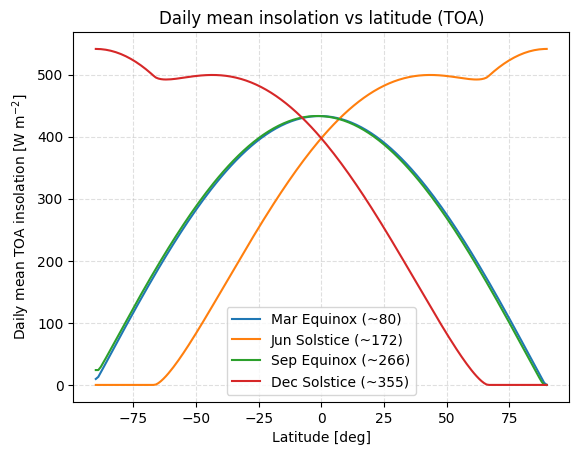

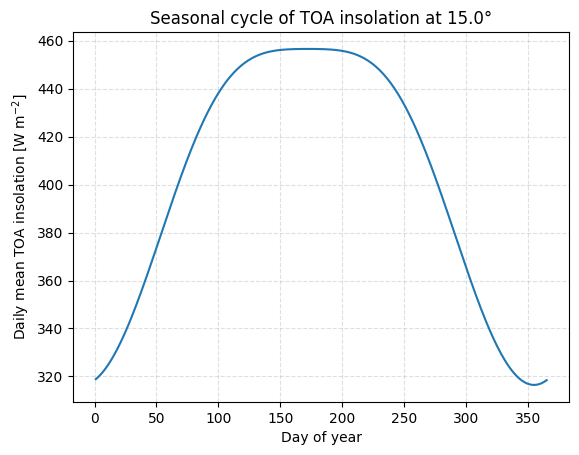

In [3]:
lats = np.linspace(-90, 90, 181)
days = {"Mar Equinox (~80)": 80, "Jun Solstice (~172)": 172, "Sep Equinox (~266)": 266, "Dec Solstice (~355)": 355}

plt.figure()
for label, doy in days.items():
    Q = np.array([daily_mean_insolation(lat, doy) for lat in lats])
    plt.plot(lats, Q, label=label)
plt.xlabel("Latitude [deg]")
plt.ylabel("Daily mean TOA insolation [W m$^{-2}$]")
plt.title("Daily mean insolation vs latitude (TOA)")
plt.grid(True, ls="--", alpha=0.4)
plt.legend()
plt.show()

lat0 = 15.0
doys = np.arange(1, 366)
Q_season = np.array([daily_mean_insolation(lat0, d) for d in doys])

plt.figure()
plt.plot(doys, Q_season)
plt.xlabel("Day of year")
plt.ylabel("Daily mean TOA insolation [W m$^{-2}$]")
plt.title(f"Seasonal cycle of TOA insolation at {lat0:.1f}°")
plt.grid(True, ls="--", alpha=0.4)
plt.show()



### Optional (recommended) check: approximate global-mean TOA insolation

For a sphere, the global-mean TOA insolation averaged over time is close to \(S_0/4\).  
Here we approximate a **global mean for a chosen day** by area-weighting with \(\cos\phi\):
\[
\langle Q \rangle \approx \frac{\int_{-90}^{90} Q(\phi)\cos\phi\, d\phi}{\int_{-90}^{90}\cos\phi\, d\phi}
\]
This is a useful check on magnitude and units.


In [4]:
# Approximate global mean for each representative day (lat-area weighting)
weights = np.cos(lats * deg2rad)
weights = weights / np.trapz(weights, lats)  # normalize over latitude degrees (approx)

for label, doy in days.items():
    Q_lat = np.array([daily_mean_insolation(lat, doy) for lat in lats])
    Q_global_approx = np.trapz(Q_lat * weights, lats)
    print(f"{label:20s}  approx global-mean Q = {Q_global_approx:7.2f} W/m^2  (compare to S0/4={S0/4:.2f})")


Mar Equinox (~80)     approx global-mean Q =  340.26 W/m^2  (compare to S0/4=340.25)
Jun Solstice (~172)   approx global-mean Q =  340.25 W/m^2  (compare to S0/4=340.25)
Sep Equinox (~266)    approx global-mean Q =  340.26 W/m^2  (compare to S0/4=340.25)
Dec Solstice (~355)   approx global-mean Q =  340.25 W/m^2  (compare to S0/4=340.25)


/tmp/ipykernel_1194/2188020184.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  weights = weights / np.trapz(weights, lats)  # normalize over latitude degrees (approx)
/tmp/ipykernel_1194/2188020184.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Q_global_approx = np.trapz(Q_lat * weights, lats)



## 3) Global-mean energy balance and effective temperature \(T_e\)

A basic planetary balance **without** greenhouse physics is:
\[
(1-\alpha)\frac{S_0}{4} = \sigma T_e^4
\]

Interpretation:
- Left-hand side is **absorbed shortwave** [W m⁻²].
- Right-hand side is emitted longwave assuming a blackbody at temperature \(T_e\).

**Important:** \(T_e\) is typically ~255 K for Earth, while the observed global-mean surface temperature is ~288 K.  
The ~33 K difference reflects the **greenhouse effect** (the effective emission level is higher/colder than the surface).

**Tasks**
1) Compute \(T_e\) and compare with ~288 K.  
2) Explain (1–2 sentences) why a greenhouse atmosphere raises surface temperature above \(T_e\).

A greenhouse atmosphere raises the surface temperature ($T_s$) because it absorbs outgoing longwave radiation and re-emits it in all directions, including back toward the ground. This "back-radiation" provides an additional energy source to the surface, forcing it to reach a higher temperature than the effective emission temperature ($T_e$) to maintain a global energy balance.

In [5]:
Q_in = (1 - alpha) * S0 / 4.0
Te = (Q_in / sigma) ** 0.25

print(f"Absorbed solar (global mean) = {Q_in:.2f} W/m^2")
print(f"Effective emission temperature Te = {Te:.2f} K")
print("Observed mean surface temperature ~ 288 K (context)")


Absorbed solar (global mean) = 238.17 W/m^2
Effective emission temperature Te = 254.58 K
Observed mean surface temperature ~ 288 K (context)



## 4) CO₂ radiative forcing (log relationship)

A widely used approximation for CO₂ radiative forcing is:
\[
\Delta F = 5.35\,\ln\left(\frac{C}{C_0}\right)
\]
where:
- \(C\), \(C_0\) are CO₂ concentrations in ppm,
- \(\Delta F\) is in W m⁻².

Why log?
- CO₂ absorption bands become progressively saturated; incremental forcing scales roughly with \(\ln C\).

**Tasks**
- Compute forcing for 280 → 420 ppm  
- Compute forcing for 280 → 560 ppm (doubling)  
- Report values and comment: why is doubling a common reference point?

For 280-420 the value is 2.169 and for 280-560 the value 3.708.Because CO_2 forcing is logarithmic, every doubling of its concentration (e.g., from 280 to 560 ppm) adds the same constant amount of heat energy—approximately 3.7\ W/m^2—to the atmosphere.This makes doubling a universal benchmark for calculating Climate Sensitivity, allowing scientists to compare the stability of different climate models and historical periods using a consistent scale.

In [6]:
def co2_forcing(C, C0=280.0):
    return 5.35 * np.log(C / C0)

for C in [420.0, 560.0]:
    dF = co2_forcing(C, 280.0)
    print(f"ΔF for 280→{C:.0f} ppm = {dF:.3f} W/m^2")


ΔF for 280→420 ppm = 2.169 W/m^2
ΔF for 280→560 ppm = 3.708 W/m^2



### Link forcing to equilibrium temperature change (useful approximation)

At equilibrium, a small perturbation around temperature \(T\) can be linearized:
\[
\sigma T^4 \approx \sigma T_0^4 + 4\sigma T_0^3 (T - T_0)
\]
So a forcing \(\Delta F\) corresponds approximately to:
\[
\Delta T_{eq} \approx \frac{\Delta F}{4\sigma T_0^3}
\]
This is a **no-feedback** estimate. Real climate sensitivity differs due to feedbacks (water vapour, clouds, ice–albedo, lapse rate).

**Task:** compute the no-feedback \(\Delta T_{eq}\) for CO₂ doubling using \(T_0=288\) K.


In [7]:
T0 = 288.0
dF2x = co2_forcing(560.0, 280.0)
dTeq_nf = dF2x / (4 * sigma * T0**3)
print(f"No-feedback equilibrium ΔT for CO2 doubling (T0=288 K): {dTeq_nf:.3f} K")


No-feedback equilibrium ΔT for CO2 doubling (T0=288 K): 0.684 K



## 5) A 0D Energy Balance Model (EBM) with mixed-layer heat capacity

We model global-mean temperature evolution:
\[
C\,\frac{dT}{dt} = (1-\alpha)\frac{S_0}{4} + \Delta F(t) - \sigma T^4
\]
where:
- \(C\) is effective heat capacity per unit area [J m⁻² K⁻¹], approximated as \(\rho_w c_{p,w} H\)
- \(H\) is a mixed-layer depth (order 10–100 m)
- \(\Delta F(t)\) is the imposed forcing (here: a step increase)

**Timescale intuition (linearized)**
Near \(T_0\), the restoring term is \(4\sigma T_0^3\), giving an approximate e-folding timescale:
\[
\tau \approx \frac{C}{4\sigma T_0^3}
\]
This is a physically interpretable “response time” of the mixed-layer system.

**Numerical note**
We use an explicit time step. If you make \(dt\) too large, the scheme can become unstable.

**Tasks**
1) Run the simulation, plot \(T(t)\).  
2) Estimate \(\tau\) and compare with how fast \(T(t)\) approaches equilibrium.  
3) Briefly comment on how changing \(H\) changes \(\tau\).

2. As shown in the plot's metadata, tau is approximately 1.2 years. The temperature T(t) approaches its new equilibrium (approx 255.6\ K) extremely rapidly; because a system typically reaches 95% of its final state within 3\tau, this model stabilizes in less than 5 years, which is reflected by the sharp "elbow" in the curve.
3. The response timescale tau is directly proportional to the mixed-layer depth H because H determines the system's total heat capacity (thermal inertia).Tau increases with decreasing H and vice versa.

Approx linearized response timescale tau ≈ 1.2 years (for H=50.0 m)


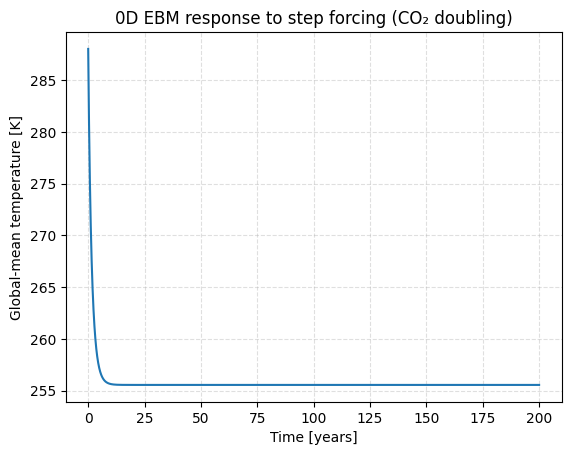

Initial T = 288.00 K; Final T (year 200) = 255.56 K


In [8]:
rho_w = 1000.0
cp_w  = 4180.0
H     = 50.0
Ccap  = rho_w * cp_w * H  # J/m^2/K

T0 = 288.0
tau_years = (Ccap / (4*sigma*T0**3)) / (365*24*3600)
print(f"Approx linearized response timescale tau ≈ {tau_years:.1f} years (for H={H} m)")

years = 200
dt = 24*3600 * 10  # 10-day
nt = int(years * 365*24*3600 / dt)

t = np.arange(nt) * dt
t_years = t / (365*24*3600)

dF_step = co2_forcing(560.0, 280.0)
dF_t = np.full(nt, dF_step)

T = np.zeros(nt)
T[0] = 288.0

for i in range(nt-1):
    rhs = (1-alpha)*S0/4 + dF_t[i] - sigma*(T[i]**4)
    T[i+1] = T[i] + (dt/Ccap)*rhs

plt.figure()
plt.plot(t_years, T)
plt.xlabel("Time [years]")
plt.ylabel("Global-mean temperature [K]")
plt.title("0D EBM response to step forcing (CO₂ doubling)")
plt.grid(True, ls="--", alpha=0.4)
plt.show()

print(f"Initial T = {T[0]:.2f} K; Final T (year {years}) = {T[-1]:.2f} K")


## Interpretation (submit, 150–250 words)
- Why \(S_0/4\) appears in global mean balance  
- What \(T_e\) vs surface temperature implies  
- Why EBM response takes decades (heat capacity)
1. The factor of 1/4 represents the ratio between the Earth's cross-sectional area (pi R^2) that intercepts sunlight and its total surface area (4 \pi R^2) that emits heat. This geometric averaging spreads the incoming solar constant S_0 over the entire spherical planet to calculate a global, 24-hour mean energy input.
2. The gap between the effective emission temperature (T_e) and the actual surface temperature indicates the presence and strength of the greenhouse effect. It implies the atmosphere is opaque to longwave radiation, trapping heat and requiring the surface to be much warmer than an airless rock to balance the incoming solar flux.
3. While a shallow mixed layer (H = 50\text{ m}) has a fast response timescale of $\tau \approx 1.2$ years, the real climate system is coupled to the deep ocean. The massive heat capacity of the full ocean depth creates "thermal inertia," acting as a giant heat sink that slows the global temperature response to decades or even centuries.